Accuracy: 86.76%
              precision    recall  f1-score   support

        bike       0.92      0.82      0.87       372
         bus       0.79      0.75      0.77       460
         car       0.87      0.79      0.83       351
        walk       0.88      0.96      0.92      1083

    accuracy                           0.87      2266
   macro avg       0.86      0.83      0.85      2266
weighted avg       0.87      0.87      0.87      2266



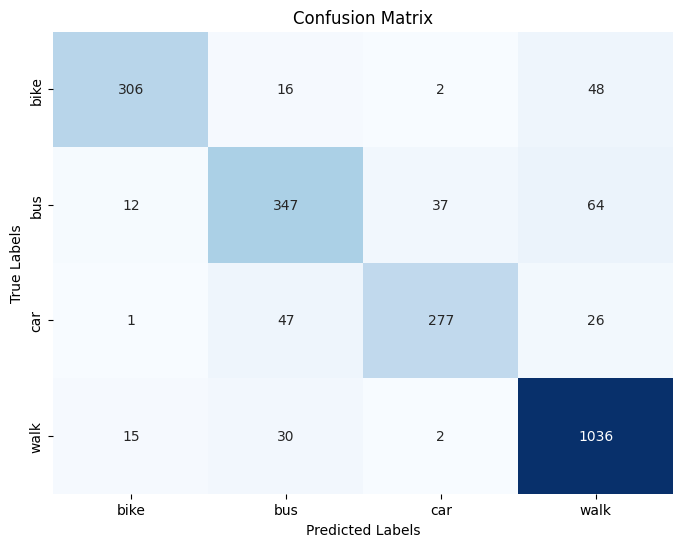

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier


df = pd.read_csv("segment_features.csv")


X = df.drop(columns=["mode", "file_name"])
y = df["mode"]

# Om det finns textkolumner förutom mode, ta bort dem automatiskt
#X = X.select_dtypes(include=["number"])


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

classifier.fit(X_train, y_train)


y_pred = classifier.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


print(classification_report(y_test, y_pred))


labels = sorted(y.unique())
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="g",
    cmap="Blues",
    cbar=False,
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


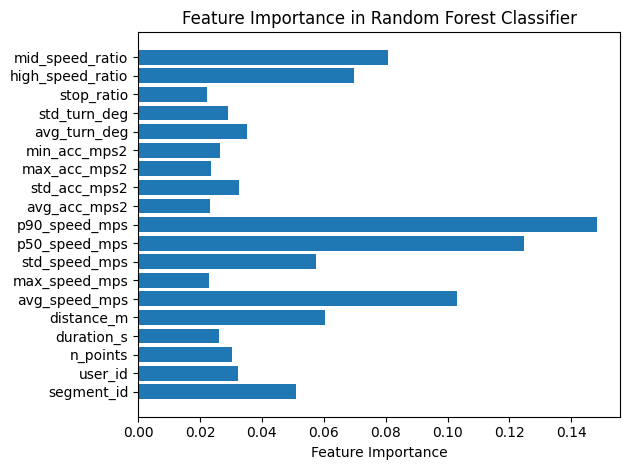

In [61]:

# Sortera från störst till minst
feature_importances = classifier.feature_importances_



plt.barh(X.columns, feature_importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
plt.tight_layout()



plt.show()

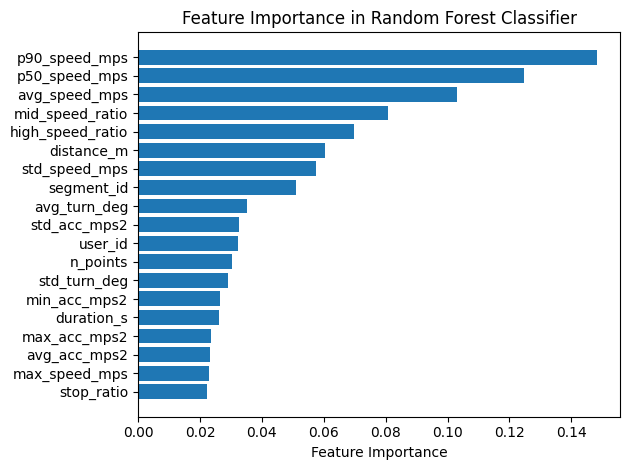

In [62]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': classifier.feature_importances_
})

# Sortera från störst till minst
importance_df = importance_df.sort_values(by='Importance', ascending=True)



plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
plt.tight_layout()



plt.show()

In [63]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print(classification_report(y_test, y_pred_knn))


              precision    recall  f1-score   support

        bike       0.83      0.81      0.82       372
         bus       0.72      0.70      0.71       460
         car       0.82      0.67      0.74       351
        walk       0.87      0.94      0.90      1083

    accuracy                           0.83      2266
   macro avg       0.81      0.78      0.79      2266
weighted avg       0.82      0.83      0.82      2266

